In [1]:
import pandas as pd
import numpy as np


In [2]:
import sys
sys.path.append("/home/pcsl/Documents/plecs/sepic/plecs_python_auto/AImodel")
import model_create as mc

# model_ripple = mc.build_residual_mlp_ripple()
model_ripple = mc.build_random_forest()
model_mos_loss = mc.build_random_forest()
model_dio_loss = mc.build_random_forest()
model_leakage = mc.build_random_forest()
model_ESR_loss = mc.build_random_forest()

I0000 00:00:1779166700.832820    7220 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:

df = pd.read_csv('/home/pcsl/Documents/plecs/sepic/plecs_python_auto/out/sepic_data/inner_loop/result_file_sepic_no_under_cpp.csv')
print(f"행 개수 :  {len(df)}")


행 개수 :  9815


In [4]:
from sklearn.preprocessing import LabelEncoder


df = df[(df["mosfet_cond_loss"] < 1000) & (df["i_L1_ripple_rate"] <= 0.7)] # maximum limitation

X = df[['L1', 'L2', 'C1', 'fs']].values
y_ripple  = df[['i_L1_ripple_rate', 'V_out_ripple_rate']].values
# y_leakage = df[['leakage_rms']].values
y_mos_loss = df[['mosfet_cond_loss', 'mosfet_switch_loss']].values
y_dio_loss = df[['diode_cond_loss']].values
y_ESR_loss = df[['L1_ESR_loss', 'L2_ESR_loss', 'C1_ESR_loss', 'C2_ESR_loss']].values

# CCM, DCM Mode 분리 model

In [5]:

splits = mc.split_data(X, y_ripple, y_mos_loss, y_dio_loss, y_ESR_loss)

X_train, X_val, X_test = splits[0]
y_ripple_train, y_ripple_val, y_ripple_test = splits[1]
y_mos_loss_train, y_mos_loss_val, y_mos_loss_test = splits[2]
y_dio_loss_train, y_dio_loss_val, y_dio_loss_test = splits[3]
# y_leakage_train, y_leakage_val, y_leakage_test = splits[4]
y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test = splits[4]

## Scaler

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# HS용
y_ripple_mmscaler  = MinMaxScaler()
y_leakage_mmscaler = MinMaxScaler()

y_ripple_mmscaler.fit_transform(y_ripple)

# 학습용
X_train, X_val, X_test, x_scaler = mc.scale_data(
    X_train, X_val, X_test,
    scaler = MinMaxScaler()
)

#ripple
y_ripple_train, y_ripple_val, y_ripple_test, y_ripple_scaler = mc.scale_data(
    y_ripple_train, y_ripple_val, y_ripple_test,
    scaler = MinMaxScaler()
)

# mosfet loss
y_mos_loss_train, y_mos_loss_val, y_mos_loss_test, y_mos_loss_scaler = mc.scale_data(
    y_mos_loss_train, y_mos_loss_val, y_mos_loss_test,
    scaler = MinMaxScaler()
)

# diode loss 
y_dio_loss_train, y_dio_loss_val, y_dio_loss_test, y_dio_loss_scaler = mc.scale_data(
    y_dio_loss_train, y_dio_loss_val, y_dio_loss_test,
    scaler = MinMaxScaler()
)

# # leakage current rms
# y_leakage_train, y_leakage_val, y_leakage_test, y_leakage_scaler =  mc.scale_data(
#     y_leakage_train, y_leakage_val, y_leakage_test,
#     scaler = StandardScaler()
# )

# ESR loss
y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test, y_ESR_loss_scaler = mc.scale_data(
    y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test,
    scaler = MinMaxScaler()
)


  Ripple Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0000     0.0001     0.0001
mae                 0.0011     0.0020     0.0021
r2                  0.9997     0.9982     0.9985


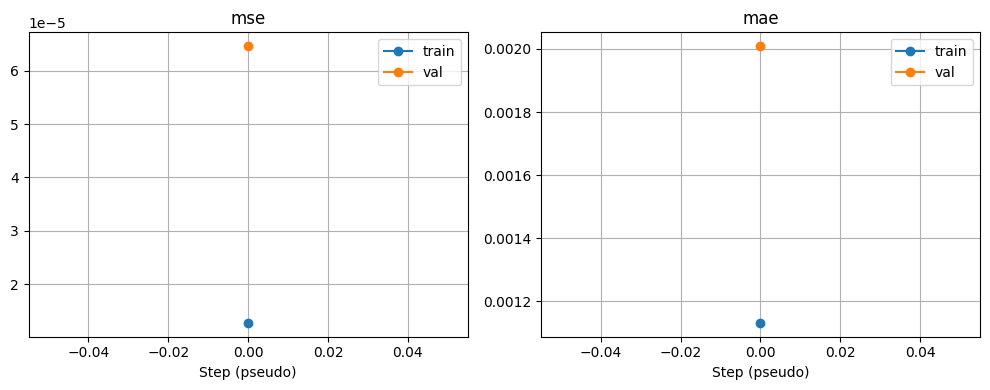


  Mosfet Loss Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0000     0.0001     0.0001
mae                 0.0023     0.0039     0.0041
r2                  0.9995     0.9981     0.9982


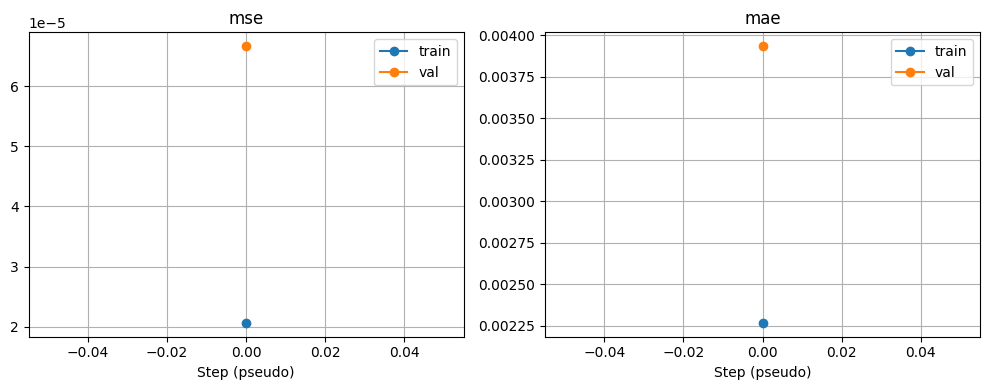

/home/pcsl/Documents/plecs/sepic/plecs_python_auto/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



  Diode Loss Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0000     0.0000     0.0001
mae                 0.0020     0.0034     0.0037
r2                  0.9995     0.9989     0.9984


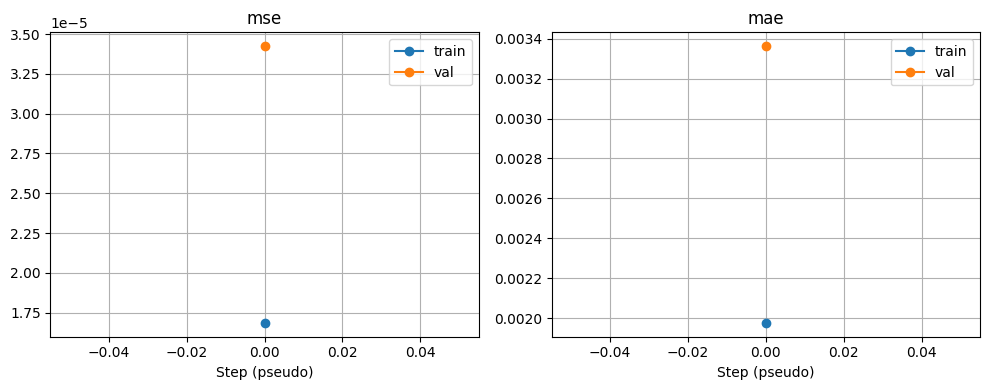


  ESR Loss Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0002     0.0005     0.0005
mae                 0.0056     0.0091     0.0095
r2                  0.9958     0.9884     0.9877


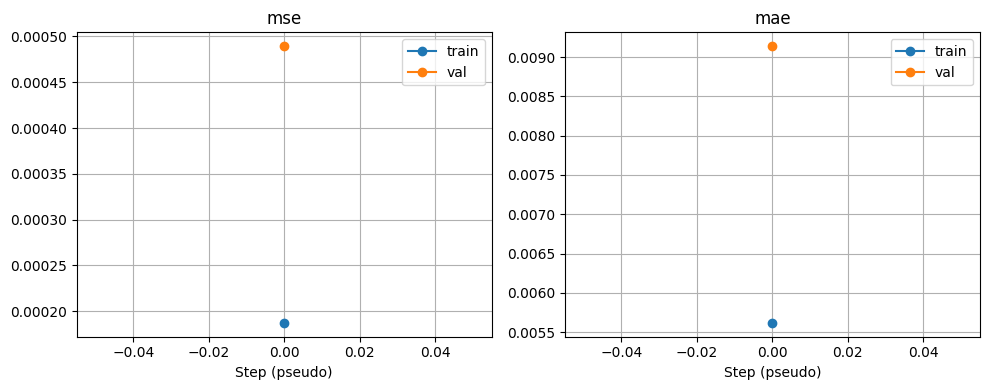

In [7]:

history_ripple = mc.train_and_evaluate_sklearn(
    model_ripple,
    X_train, y_ripple_train,
    X_val,   y_ripple_val,
    X_test,  y_ripple_test,
    model_name='Ripple Model',
)

history_mosfet = mc.train_and_evaluate_sklearn(
    model_mos_loss,
    X_train, y_mos_loss_train,
    X_val,   y_mos_loss_val,
    X_test,  y_mos_loss_test,
    model_name='Mosfet Loss Model',
)

history_diode = mc.train_and_evaluate_sklearn(
    model_dio_loss,
    X_train, y_dio_loss_train,
    X_val,   y_dio_loss_val,
    X_test,  y_dio_loss_test,
    model_name='Diode Loss Model',
)

# history_leakage = mc.train_and_evaluate(
#     model_leakage,
#     X_train, y_leakage_train,
#     X_val,   y_leakage_val,
#     X_test,  y_leakage_test,
#     model_name='Leakage Current Model',
#     epochs=1000, batch_size=100
# )

history_ESR = mc.train_and_evaluate_sklearn(
    model_ESR_loss,
    X_train, y_ESR_loss_train,
    X_val,   y_ESR_loss_val,
    X_test,  y_ESR_loss_test,
    model_name='ESR Loss Model',
)



# hs

In [8]:
from harmonicSearchtest import *

model_dict ={}
model_dict["ripple"] = model_ripple
model_dict["mos_loss"] = model_mos_loss
model_dict["dio_loss"] = model_dio_loss
model_dict["leakage_current"] = model_leakage
model_dict["ESR_loss"] = model_ESR_loss


scaler_dict = {}

scaler_dict["mm_x"] = x_scaler
scaler_dict["std_ripple"] = y_ripple_scaler
scaler_dict["std_mos_loss"] = y_mos_loss_scaler
scaler_dict["std_dio_loss"] = y_dio_loss_scaler
# scaler_dict["std_leakage_current"] = y_leakage_scaler
scaler_dict["std_ESR_loss"] = y_ESR_loss_scaler
scaler_dict["mm_ripple"] = y_ripple_mmscaler


In [ ]:
import pandas as pd
import numpy as np

# 원본 입력 DataFrame
df_input = pd.DataFrame(
    X,
    columns=["L1", "L2", "C1", "fs"]
)

# X scaling
scale_X = x_scaler.transform(X)

# predict
predict_ripple = model_ripple.predict(scale_X)
predict_mos_loss = model_mos_loss.predict(scale_X)
predict_dio_loss = model_dio_loss.predict(scale_X)
print(predict_dio_loss.shape)
predict_ESR_loss = model_ESR_loss.predict(scale_X)

# inverse transform
ripple = y_ripple_scaler.inverse_transform(predict_ripple)
mos_loss = y_mos_loss_scaler.inverse_transform(predict_mos_loss)
dio_loss = y_dio_loss_scaler.inverse_transform( predict_dio_loss.reshape(-1, 1))
esr_loss = y_ESR_loss_scaler.inverse_transform(predict_ESR_loss)

# 결과 합치기
result = np.concatenate(
    [
        esr_loss[:, [2]],   # C1_ESR_loss
        esr_loss[:, [3]],   # C2_ESR_loss
        esr_loss[:, [0]],   # L1_ESR_loss
        esr_loss[:, [1]],   # L2_ESR_loss
        dio_loss[:, [0]],   # diode_cond_loss
        mos_loss[:, [0]],   # mosfet_cond_loss
        mos_loss[:, [1]],   # mosfet_switch_loss
        ripple[:, [0]],     # i_L1_ripple_rate
        ripple[:, [1]],     # V_out_ripple_rate
    ],
    axis=1
)

name_list = [
    "C1_ESR_loss",
    "C2_ESR_loss",
    "L1_ESR_loss",
    "L2_ESR_loss",
    "diode_cond_loss",
    "mosfet_cond_loss",
    "mosfet_switch_loss",
    "i_L1_ripple_rate",
    "V_out_ripple_rate",
]

# prediction DataFrame
df_pred = pd.DataFrame(result, columns=name_list)

# 입력 + prediction 합치기
df_result = pd.concat([df_input, df_pred], axis=1)

# 저장
df_result.to_csv("prediction_random_forest_results.csv", index=False)

print(df_result.head())

(8895,)
        L1        L2        C1       fs  C1_ESR_loss  C2_ESR_loss  \
0  0.00022  0.000025  0.000001  55600.0   648.024587     1.519297   
1  0.00022  0.000025  0.000001  61100.0   622.113867     1.526247   
2  0.00022  0.000025  0.000001  66700.0   484.293970     1.461450   
3  0.00022  0.000025  0.000001  72200.0   479.197767     1.463760   
4  0.00022  0.000025  0.000001  77800.0   431.917327     1.525410   

   L1_ESR_loss  L2_ESR_loss  diode_cond_loss  mosfet_cond_loss  \
0    11.332127    76.241048        58.438792         14.048167   
1    12.444670    78.906452        58.421039         13.978129   
2     9.104824    62.706593        58.362767         13.795922   
3     9.205442    64.116935        58.299782         13.680053   
4     8.813947    62.991153        58.240716         13.594297   

   mosfet_switch_loss  i_L1_ripple_rate  V_out_ripple_rate  
0            2.464380          0.693254           0.037806  
1            2.674628          0.638424           0.033406

In [ ]:
import pandas as pd
import os
save_path = "hs_results_random_forest.csv"
for i in range(300):

    best_x, best_m, best_f, history = harmony_search(
        model=model_dict,
        scaler=scaler_dict,
        hms=100,
        max_iters=500,
        hmcr=0.7,
    )

    # 한 줄 데이터 생성
    row = {
        "run": i + 1,
        "best_f": float(best_f),
    }

    # best_x 저장
    for k, v in best_x.items():
        row[k] = float(v)

    # best_m 저장
    for k, v in best_m.items():
        row[k] = float(v)

    df_row = pd.DataFrame([row])

    # 파일 존재 여부 확인
    if not os.path.exists(save_path):
        # 처음이면 헤더 포함 저장
        df_row.to_csv(save_path, index=False, mode="w")
    else:
        # 이후에는 append
        df_row.to_csv(save_path, index=False, mode="a", header=False)

    print(f"[{i+1}] saved | best_f = {best_f:.6f}")

[1] saved | best_f = 157.843462
[2] saved | best_f = 155.959688
[3] saved | best_f = 155.776631
[4] saved | best_f = 155.770304


In [ ]:
def evaluate_to_dict(model, X, y):
    results = model.evaluate(X, y, verbose=0)
    return dict(zip(model.metrics_names, results))

evaluate_to_dict(model_mos_loss, X_test,  y_mos_loss_test)
print(X[100])
# y_mos_loss_scaler.transform(X)
scaled_X = x_scaler.transform(X)
print(scaled_X[100])

y = model_mos_loss.predict(np.asarray([scaled_X[100]]))
print(y)

print(y_mos_loss_scaler.inverse_transform(y))


[2.20e-04 4.50e-05 6.00e-06 6.11e+04]
[0.         0.11111111 0.20833333 0.222     ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[-1.1405166 -0.9888282]]
[[13.000656   2.4827156]]


In [ ]:
# print(model_mos_loss.predict(np.array([[0.0008398530498772605, 0.00011598542992465022, 1e-05, 4.728660689028364e-05]])))

# print(y_mos_loss_scaler.inverse_transform(model_mos_loss.predict(np.array([[0.0008398530498772605, 0.00011598542992465022, 1e-05, 4.728660689028364e-05]]))))

print(y_mos_loss_scaler.mean_)
print(y_mos_loss_scaler.scale_)

print(y_mos_loss[:20])
print(y_mos_loss_train[:5])


[13.89970139  3.16522131]
[0.78827888 0.69021666]
[[14.11663344  2.33223085]
 [13.91064862  2.57110271]
 [13.75052416  2.81255422]
 [13.62767078  3.04849042]
 [13.52857466  3.29331479]
 [13.45027299  3.53555422]
 [13.38524286  3.78147515]
 [13.33270771  4.02246836]
 [13.28841266  4.26743397]
 [13.02896662  2.21824433]
 [12.95330337  2.45037388]
 [12.89623938  2.68623063]
 [12.85426487  2.91752679]
 [12.82240274  3.15665692]
 [12.79908874  3.39337612]
 [12.7814624   3.63434235]
 [12.76886832  3.87100482]
 [12.75986597  4.11201272]
 [12.92123886  2.20646558]
 [12.85711252  2.43780281]]
[[-0.56077127  1.49470238]
 [ 1.28211543  1.40492121]
 [-0.09553478 -0.57382193]
 [-1.26468833  1.04278786]
 [ 0.80196253  1.39303902]]


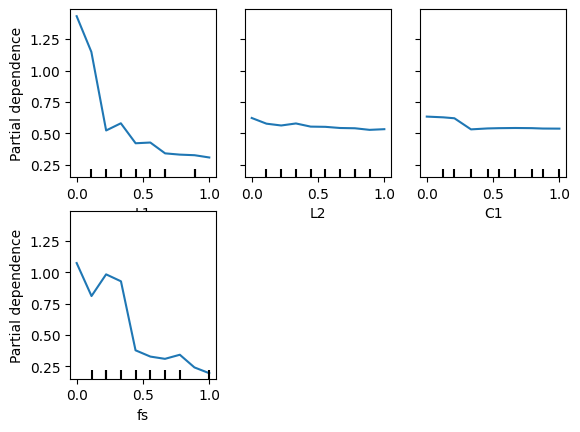

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [0, 1, 2, 3]

PartialDependenceDisplay.from_estimator(
    model_ripple,
    X_train,
    features=features,
    feature_names=["L1", "L2", "C1", "fs"]
)

plt.show()

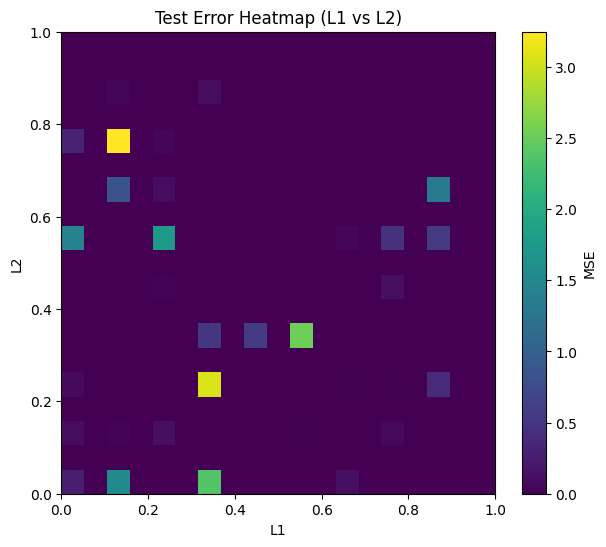

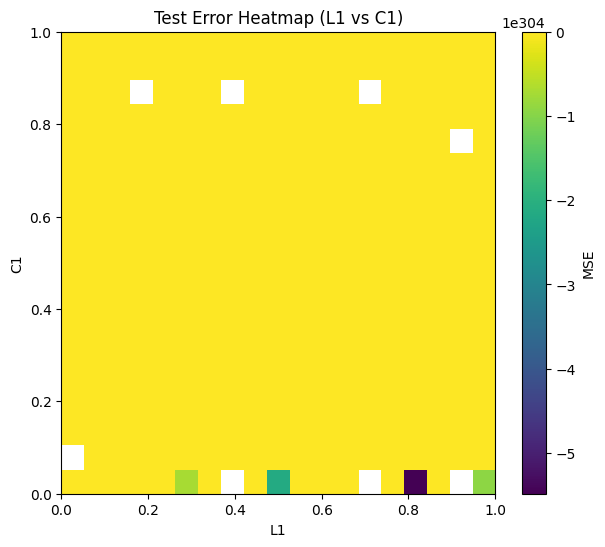

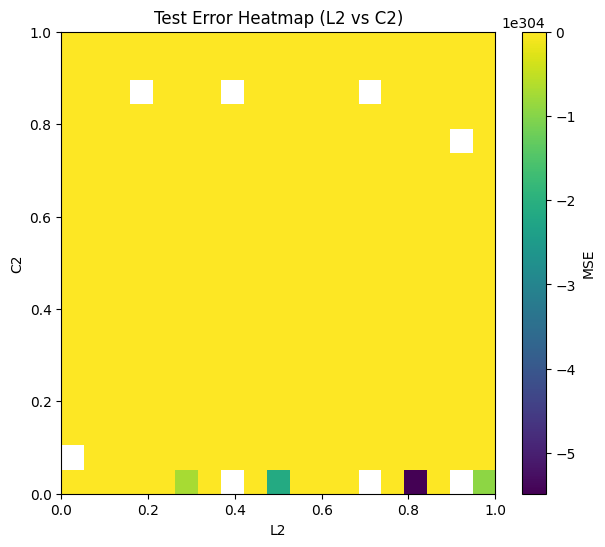

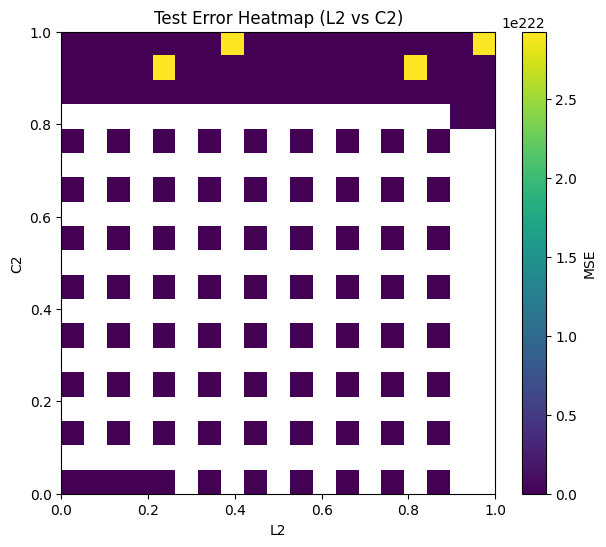

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# prediction
y_pred_scaled = model_ripple.predict(X_test)

y_pred = y_ripple_scaler.inverse_transform(y_pred_scaled)
y_true = y_ripple_scaler.inverse_transform(y_ripple_test)

# sample-wise error
errors = np.mean((y_true - y_pred)**2, axis=1)

L1 = X_test[:, 0]
L2 = X_test[:, 1]
C1 = X_test[:, 2]
C2  = X_test[:, 3]

def plot_heatmap(x, y, z, xlabel, ylabel, title, bins=20):

    x_bins = np.linspace(x.min(), x.max(), bins)
    y_bins = np.linspace(y.min(), y.max(), bins)

    heatmap = np.zeros((bins-1, bins-1))
    count = np.zeros((bins-1, bins-1))

    for i in range(len(x)):
        xi = np.digitize(x[i], x_bins) - 1
        yi = np.digitize(y[i], y_bins) - 1

        if 0 <= xi < bins-1 and 0 <= yi < bins-1:
            heatmap[yi, xi] += z[i]
            count[yi, xi] += 1

    # 평균 error
    heatmap = np.divide(heatmap, count, where=count != 0)

    plt.figure(figsize=(7,6))
    plt.imshow(heatmap, origin='lower', aspect='auto',
               extent=[x.min(), x.max(), y.min(), y.max()])
    plt.colorbar(label='MSE')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_heatmap(
    L1, L2, errors,
    xlabel="L1",
    ylabel="L2",
    title="Test Error Heatmap (L1 vs L2)"
)

plot_heatmap(
    L1, C1, errors,
    xlabel="L1",
    ylabel="C1",
    title="Test Error Heatmap (L1 vs C1)"
)


plot_heatmap(
    L2, C2, errors,
    xlabel="L2",
    ylabel="C2",
    title="Test Error Heatmap (L2 vs C2)"
)

plot_heatmap(
    L1, C2, errors,
    xlabel="L2",
    ylabel="C2",
    title="Test Error Heatmap (L2 vs C2)"
)